# DSC 540 — Weeks 1 & 2: Python Fundamentals + World Population Visualization

This notebook covers:
1. **List operations** — creating a list, iterating, sorting, and appending random numbers
2. **Matplotlib line chart** — visualizing world population growth (1960–2009)

## Part 1: Lists, Iteration, Sorting & Random Numbers

In [1]:
import random
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

random.seed(42)  # Seed for reproducibility

In [2]:
# --- Create a list of world regions ---
regions = ['Asia', 'Africa', 'Europe', 'North America', 'South America', 'Oceania', 'Antarctica']

print('Original list:')
for i, region in enumerate(regions, start=1):
    print(f'  {i}. {region}')

Original list:
  1. Asia
  2. Africa
  3. Europe
  4. North America
  5. South America
  6. Oceania
  7. Antarctica


In [3]:
# --- Sort the list ---
sorted_asc = sorted(regions)
sorted_desc = sorted(regions, reverse=True)

print('Sorted ascending:')
for i, r in enumerate(sorted_asc, start=1):
    print(f'  {i}. {r}')

print()
print('Sorted descending:')
for i, r in enumerate(sorted_desc, start=1):
    print(f'  {i}. {r}')

Sorted ascending:
  1. Africa
  2. Antarctica
  3. Asia
  4. Europe
  5. North America
  6. Oceania
  7. South America

Sorted descending:
  1. South America
  2. Oceania
  3. North America
  4. Europe
  5. Asia
  6. Antarctica
  7. Africa


In [4]:
# --- Generate random population estimates (billions) and append to list ---
random_pops = [round(random.uniform(0.1, 5.0), 3) for _ in range(5)]

print('Randomly generated population values (billions):')
for val in random_pops:
    print(f'  {val}B')

# Build (region, population) pairs and append two new entries
region_pop_list = list(zip(sorted_asc[:5], random_pops))
region_pop_list.append(('Generated Region A', round(random.uniform(0.5, 3.0), 3)))
region_pop_list.append(('Generated Region B', round(random.uniform(0.5, 3.0), 3)))

print()
print('Extended list (region, estimated population in billions):')
for item in region_pop_list:
    print(f'  {item[0]}: {item[1]}B')

Randomly generated population values (billions):
  3.233B
  0.223B
  1.448B
  1.194B
  3.709B

Extended list (region, estimated population in billions):
  Africa: 3.233B
  Antarctica: 0.223B
  Asia: 1.448B
  Europe: 1.194B
  North America: 3.709B
  Generated Region A: 2.192B
  Generated Region B: 2.73B


In [5]:
# --- Sort by population descending and print final results ---
region_pop_list.sort(key=lambda x: x[1], reverse=True)

print('Final list sorted by population (descending):')
print(f'{"Rank":<6}{"Region":<22}{"Population (B)"}')
print('-' * 42)
for rank, (region, pop) in enumerate(region_pop_list, start=1):
    print(f'{rank:<6}{region:<22}{pop}')

Final list sorted by population (descending):
Rank  Region                Population (B)
------------------------------------------
1     North America         3.709
2     Africa                3.233
3     Generated Region B    2.73
4     Generated Region A    2.192
5     Asia                  1.448
6     Europe                1.194
7     Antarctica            0.223


---
## Part 2: World Population Line Chart

Data source: `world-population.csv` (Bellevue University DSC 540)  
Coverage: **1960–2009** — annual global population estimates.

In [6]:
# --- Data embedded directly so the notebook runs anywhere ---
import io

csv_data = """Year,Population
1960,3028654024
1961,3068356747
1962,3121963107
1963,3187471383
1964,3253112403
1965,3320396924
1966,3390712300
1967,3460521851
1968,3531547287
1969,3606994959
1970,3682870688
1971,3761750672
1972,3839147707
1973,3915742695
1974,3992806090
1975,4068032705
1976,4141383058
1977,4214499013
1978,4288485981
1979,4363754326
1980,4439638086
1981,4516734312
1982,4595890494
1983,4675178812
1984,4753877875
1985,4834206631
1986,4918126890
1987,5004006066
1988,5090899475
1989,5178059174
1990,5266783430
1991,5351836347
1992,5433823608
1993,5516863641
1994,5598658151
1995,5681689325
1996,5762235749
1997,5842585301
1998,5921799957
1999,6001269553
2000,6078274622
2001,6155652495
2002,6232413711
2003,6309266583
2004,6385778679
2005,6462054420
2006,6538196688
2007,6614396907
2008,6692030277
2009,6775235741
"""

df = pd.read_csv(io.StringIO(csv_data))
print(f'Rows: {len(df)}')
print(f'Years: {df["Year"].min()} – {df["Year"].max()}')
df.head()

Rows: 50
Years: 1960 – 2009


,Year,Population
0,1960,3028654024
1,1961,3068356747
2,1962,3121963107
3,1963,3187471383
4,1964,3253112403


In [7]:
# --- Add a column in billions for readability ---
df['Population_B'] = df['Population'] / 1_000_000_000
df.describe()

,Year,Population,Population_B
count,50.00000,5.000000e+01,50.000000
mean,1984.50000,4.837313e+09,4.837313
std,14.57738,1.145702e+09,1.145702
min,1960.00000,3.028654e+09,3.028654
25%,1972.25000,3.858296e+09,3.858296
50%,1984.50000,4.794042e+09,4.794042
75%,1996.75000,5.822498e+09,5.822498
max,2009.00000,6.775236e+09,6.775236


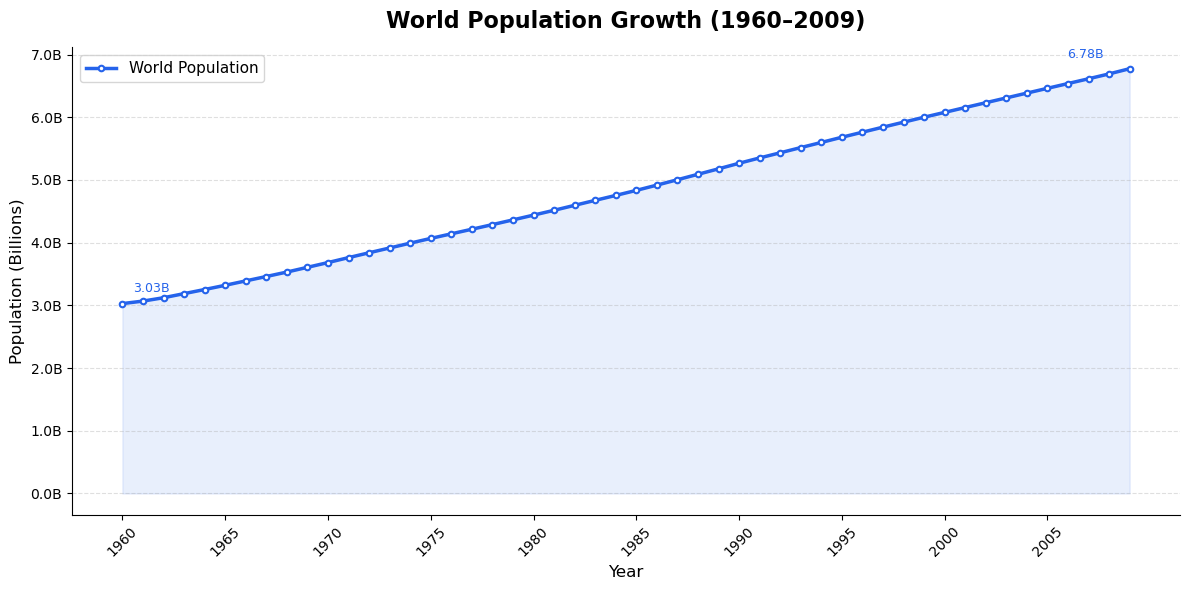

Chart saved as world_population_chart.png


In [8]:
# --- Build the line chart ---
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    df['Year'], df['Population_B'],
    color='#2563EB', linewidth=2.5,
    marker='o', markersize=4, markerfacecolor='white', markeredgewidth=1.5,
    label='World Population'
)

# Shade the area under the line
ax.fill_between(df['Year'], df['Population_B'], alpha=0.10, color='#2563EB')

# Annotate start and end points
ax.annotate(
    f"{df['Population_B'].iloc[0]:.2f}B",
    xy=(df['Year'].iloc[0], df['Population_B'].iloc[0]),
    xytext=(8, 8), textcoords='offset points',
    fontsize=9, color='#2563EB'
)
ax.annotate(
    f"{df['Population_B'].iloc[-1]:.2f}B",
    xy=(df['Year'].iloc[-1], df['Population_B'].iloc[-1]),
    xytext=(-45, 8), textcoords='offset points',
    fontsize=9, color='#2563EB'
)

# Labels, title, formatting
ax.set_title('World Population Growth (1960–2009)', fontsize=16, fontweight='bold', pad=14)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Population (Billions)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}B'))
ax.set_xticks(range(1960, 2010, 5))
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('world_population_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as world_population_chart.png')